# Week 4 — LSTM Model + Copilot Agent Skeleton

**Part A:** Implement a basic LSTM model for sequence-based RUL prediction

**Part B:** Define the Copilot tool contract and build a rule-based orchestrator

**Learning Goals:**
- Transition from tabular ML to sequence models
- Understand what "agentic" means: tool calling + orchestration + guardrails

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.insert(0, '../src')
from data_loader import load_train, load_test
from preprocess import preprocess_pipeline, INFORMATIVE_SENSORS_FD001
from models.lstm import LSTMModel
from train import train_model, compute_metrics

plt.style.use('seaborn-v0_8-whitegrid')
device = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: mps


## Part A: LSTM Model

In [10]:
# Load and preprocess data
df_train = load_train(fd_number=1, rul_cap=125)
df_test, rul_true = load_test(fd_number=1)

data = preprocess_pipeline(df_train, df_test, window_size=30, rul_cap=125)

print(f'X_train: {data["X_train"].shape}')
print(f'y_train: {data["y_train"].shape}')
print(f'X_val:   {data["X_val"].shape}')
print(f'X_test:  {data["X_test"].shape}')

X_train: (14241, 30, 14)
y_train: (14241,)
X_val:   (3490, 30, 14)
X_test:  (100, 30, 14)


In [11]:
# Create DataLoaders
BATCH_SIZE = 256

train_ds = TensorDataset(torch.tensor(data['X_train']), torch.tensor(data['y_train']))
val_ds = TensorDataset(torch.tensor(data['X_val']), torch.tensor(data['y_val']))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

print(f'Train batches: {len(train_loader)}, Val batches: {len(val_loader)}')

Train batches: 56, Val batches: 14


In [12]:
# Create model
n_features = data['config']['n_features']
model = LSTMModel(n_features=n_features, hidden_size=64, n_layers=2, dropout=0.3)
print(f'Model parameters: {sum(p.numel() for p in model.parameters()):,}')
print(model)

Model parameters: 57,985
LSTMModel(
  (lstm): LSTM(14, 64, num_layers=2, batch_first=True, dropout=0.3)
  (fc): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [13]:
# Train
result = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    n_epochs=50,
    lr=1e-3,
    patience=10,
    save_dir='../checkpoints',
    model_name='lstm_FD001',
    device=device,
)

print(f'\nBest val loss: {result["best_val_loss"]:.4f}')

Training on: mps
Epoch   1/50 | Train Loss: 7582.0088 | Val Loss: 6295.0441 | Val MAE: 69.18 | Val RMSE: 80.08
Epoch   5/50 | Train Loss: 1390.2448 | Val Loss: 593.9678 | Val MAE: 20.52 | Val RMSE: 24.58
Epoch  10/50 | Train Loss: 390.7333 | Val Loss: 236.5566 | Val MAE: 11.53 | Val RMSE: 15.53
Epoch  15/50 | Train Loss: 337.8350 | Val Loss: 173.5993 | Val MAE: 9.81 | Val RMSE: 13.25
Epoch  20/50 | Train Loss: 314.2171 | Val Loss: 174.5331 | Val MAE: 10.44 | Val RMSE: 13.30
Epoch  25/50 | Train Loss: 301.8838 | Val Loss: 165.9290 | Val MAE: 9.76 | Val RMSE: 12.96
Epoch  30/50 | Train Loss: 280.5889 | Val Loss: 153.5402 | Val MAE: 9.15 | Val RMSE: 12.47
Early stopping at epoch 33

Best val loss: 147.2316


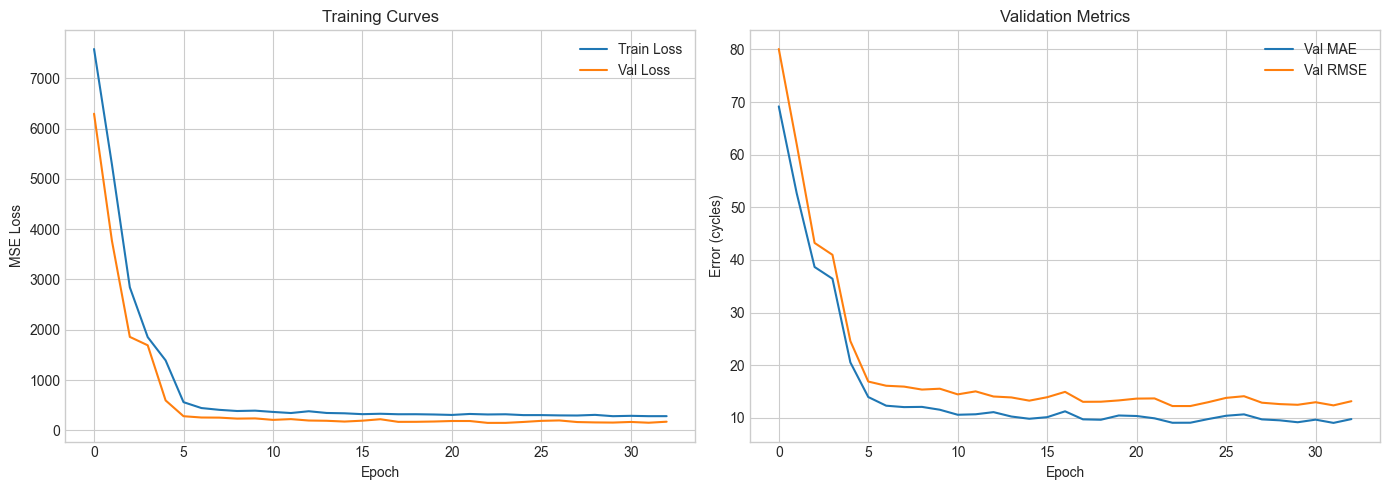

In [14]:
# Training curves
history = result['history']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history['train_loss'], label='Train Loss')
axes[0].plot(history['val_loss'], label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Training Curves')
axes[0].legend()

axes[1].plot(history['val_mae'], label='Val MAE')
axes[1].plot(history['val_rmse'], label='Val RMSE')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Error (cycles)')
axes[1].set_title('Validation Metrics')
axes[1].legend()

plt.tight_layout()
plt.show()

In [15]:
# Test evaluation
model_trained = result['model']
model_trained.eval()

X_test_t = torch.tensor(data['X_test'], dtype=torch.float32).to(result['device'])
with torch.no_grad():
    test_preds = model_trained(X_test_t).squeeze(-1).cpu().numpy()

test_metrics = compute_metrics(rul_true, test_preds)
print(f'LSTM Test Results:')
print(f'  MAE:        {test_metrics["MAE"]:.2f}')
print(f'  RMSE:       {test_metrics["RMSE"]:.2f}')
print(f'  NASA Score: {test_metrics["NASA_Score"]:.0f}')

LSTM Test Results:
  MAE:        12.88
  RMSE:       17.47
  NASA Score: 401


## Part B: Copilot Agent Skeleton

Define the tool contract and build a simple rule-based orchestrator.

In [16]:
# Test the copilot tools individually
from copilot.tools import predict_rul, explain_prediction, retrieve_knowledge, recommend_action

# Pick an engine window from test set
engine_idx = 0
engine_window = data['X_test'][engine_idx]
print(f'Engine window shape: {engine_window.shape}')

# Tool 1: Predict
pred = predict_rul(engine_window, model=model_trained, mc_samples=0, device=str(result['device']))
print(f'\nPrediction: {pred}')

# Tool 2: Explain (use CPU — gradient computation is unreliable on MPS)
expl = explain_prediction(engine_window, model=model_trained, method='saliency', device='cpu')
print(f'\nTop sensors: {expl["top_sensors"][:3]}')

# Tool 3: Retrieve KB
kb = retrieve_knowledge('HPC degradation sensor maintenance')
print(f'\nKB snippets: {len(kb["snippets"])} found')

# Tool 4: Recommend
rec = recommend_action(pred, expl, kb)
print(f'\nRecommendation: {rec["action"]} — {rec["recommendation"][:100]}...')

Engine window shape: (30, 14)

Prediction: {'rul_mean': 98.2107162475586, 'rul_std': None, 'confidence_interval_95': None, 'uncertainty_level': 'unknown'}

Top sensors: [{'sensor': 'sensor_9', 'importance': 4.174684047698975, 'rank': 1}, {'sensor': 'sensor_8', 'importance': 3.829525947570801, 'rank': 2}, {'sensor': 'sensor_11', 'importance': 3.5810649394989014, 'rank': 3}]

KB snippets: 3 found

Recommendation: recommend — NORMAL: Predicted RUL = 98 cycles. Continue monitoring. No immediate action required. Primary degrad...


In [17]:
# Demo the full Copilot pipeline
from copilot.agent import OpsCopilot

copilot = OpsCopilot(
    model=model_trained,
    sensor_names=INFORMATIVE_SENSORS_FD001,
    mc_samples=0,  # No MC dropout for plain LSTM
    device='cpu',  # Gradient-based explanations require CPU (MPS doesn't support requires_grad properly)
)

# Analyze one engine
report = copilot.analyze_engine(data['X_test'][0], engine_id=1)
print(copilot.format_report(report))

═══ Engine 1 Analysis ═══

📊 Prediction:
   RUL = 98 cycles

🔍 Top Contributing Sensors:
   1. sensor_12 (importance: 1.3969)
   2. sensor_7 (importance: 1.3534)
   3. sensor_20 (importance: 0.9421)

💡 Recommendation (RECOMMEND):
   NORMAL: Predicted RUL = 98 cycles. Continue monitoring. No immediate action required. Primary degradation signal: sensor_12. KB reference: - **sensor_2** (T2): Total temperature at fan inlet — may shift as HPC efficiency drops - **sensor_3** (T24): Total temperature at LPC outlet — rises with compressor inefficiency - **sensor_4** (T30):
   Confidence: medium

✅ Safety Checks:
   Uncertainty reported: ✗
   KB cited: ✓
   No false reassurance: ✓
